In [27]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [28]:
# Cargar el dataset MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [29]:
print(x_test.shape)
print(x_train.shape)

(10000, 28, 28)
(60000, 28, 28)


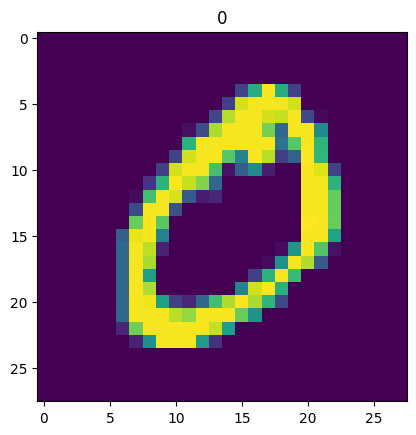

In [33]:
i= 1
plt.imshow(x_train[i])
plt.title(y_train[i])
plt.show()

In [34]:
# Normalizar las imágenes (de 0-255 a 0-1)
x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# Aplanar las imágenes de 28x28 a 784
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# Guardar las etiquetas originales para evitar errores posteriores
y_train_raw = y_train.copy()
y_test_raw = y_test.copy()

# Convertir las etiquetas a one-hot (y asegurarse que sean float32)
y_train = np.eye(10)[y_train_raw].astype(np.float32)
y_test = np.eye(10)[y_test_raw].astype(np.float32)

In [35]:
x_train[i]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [8]:
y_train[i]

array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0.], dtype=float32)

In [9]:
# --- 2. Definir la red neuronal feedforward (sin Keras) ---
class FeedForwardNN(tf.Module):
    def __init__(self):
        super().__init__()
        # Inicializar pesos y sesgos manualmente
        self.w1 = tf.Variable(tf.random.normal([784, 128], stddev=0.1), name="w1")
        self.b1 = tf.Variable(tf.zeros([128]), name="b1")
        
        self.w2 = tf.Variable(tf.random.normal([128, 64], stddev=0.1), name="w2")
        self.b2 = tf.Variable(tf.zeros([64]), name="b2")
        
        self.w3 = tf.Variable(tf.random.normal([64, 10], stddev=0.1), name="w3")
        self.b3 = tf.Variable(tf.zeros([10]), name="b3")

    def __call__(self, x):
        z1 = tf.nn.relu(tf.matmul(x, self.w1) + self.b1)
        z2 = tf.nn.relu(tf.matmul(z1, self.w2) + self.b2)
        logits = tf.matmul(z2, self.w3) + self.b3
        return tf.nn.softmax(logits)

# Crear modelo
model = FeedForwardNN()

# --- 3. Definir pérdida y optimizador ---
def compute_loss(y_true, y_pred):
    return tf.reduce_mean(tf.reduce_sum(-y_true * tf.math.log(y_pred + 1e-8), axis=1))  # +1e-8 para evitar log(0)

optimizer = tf.optimizers.Adam(learning_rate=0.001)

# --- 4. Paso de entrenamiento ---
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        y_pred = model(x_batch)
        loss = compute_loss(y_batch, y_pred)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

# --- 5. Entrenar la red ---
epochs = 5
batch_size = 64
num_batches = x_train.shape[0] // batch_size

for epoch in range(epochs):
    avg_loss = 0
    for i in range(num_batches):
        batch_start = i * batch_size
        batch_end = batch_start + batch_size
        x_batch = tf.convert_to_tensor(x_train[batch_start:batch_end])
        y_batch = tf.convert_to_tensor(y_train[batch_start:batch_end])
        
        loss = train_step(x_batch, y_batch)
        avg_loss += loss.numpy()
    
    avg_loss /= num_batches
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# --- 6. Evaluar precisión en test ---
def evaluate(x_data, y_true):
    y_pred = model(tf.convert_to_tensor(x_data))
    correct = tf.equal(tf.argmax(y_pred, axis=1), tf.argmax(y_true, axis=1))
    return tf.reduce_mean(tf.cast(correct, tf.float32)).numpy()

accuracy = evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")



2025-09-17 10:37:41.287787: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-09-17 10:37:41.288079: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-09-17 10:37:41.288779: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-09-17 10:37:41.288835: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-09-17 10:37:41.289072: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/5, Loss: 0.3169
Epoch 2/5, Loss: 0.1319
Epoch 3/5, Loss: 0.0902
Epoch 4/5, Loss: 0.0663
Epoch 5/5, Loss: 0.0496
Test Accuracy: 96.55%


In [11]:
# --- 7. Visualizar una predicción ---

def mostrar_prediccion(i):
    # Obtener imagen y etiqueta reales
    imagen = x_test[i].reshape(28, 28)
    etiqueta_real = np.argmax(y_test[i])

    # Obtener predicción
    entrada = tf.convert_to_tensor(x_test[i:i+1])  # Mantener batch de 1
    prediccion = model(entrada)
    etiqueta_predicha = tf.argmax(prediccion, axis=1).numpy()[0]

    # Mostrar imagen con título
    plt.imshow(imagen, cmap='gray')
    plt.title(f"Etiqueta real: {etiqueta_real} - Predicción: {etiqueta_predicha}")
    plt.axis('off')
    plt.show()




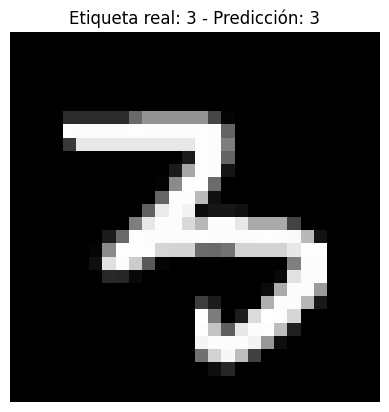

In [41]:
mostrar_prediccion(2300)

In [ ]:
# --- 8. Visualizar errores del modelo ---
def obtener_indices_mal_clasificados():
    predicciones = model(tf.convert_to_tensor(x_test))
    pred_clases = tf.argmax(predicciones, axis=1).numpy()
    etiquetas_reales = tf.argmax(y_test, axis=1).numpy()
    indices_incorrectos = np.where(pred_clases != etiquetas_reales)[0]
    return indices_incorrectos

def mostrar_error(i_error):
    indices_incorrectos = obtener_indices_mal_clasificados()
    if len(indices_incorrectos) == 0:
        print("No hay errores. El modelo clasificó todo correctamente (¡sospechoso!).")
        return
    
    i = indices_incorrectos[i_error]
    imagen = x_test[i].reshape(28, 28)
    etiqueta_real = np.argmax(y_test[i])
    entrada = tf.convert_to_tensor(x_test[i:i+1])
    prediccion = model(entrada)
    etiqueta_predicha = tf.argmax(prediccion, axis=1).numpy()[0]

    plt.imshow(imagen, cmap='gray')
    plt.title(f"[Mal clasificado] Índice: {i}\nEtiqueta real: {etiqueta_real} - Predicción: {etiqueta_predicha}", color='red')
    plt.axis('off')
    plt.show()

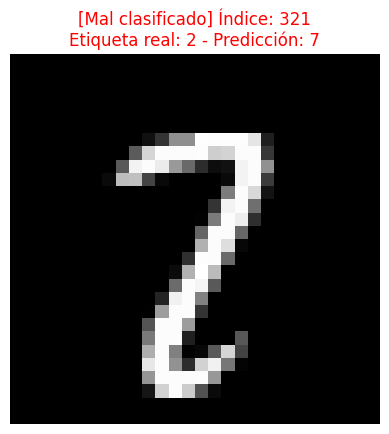

In [48]:
mostrar_error(5)


In [16]:
import tensorflow as tf
import numpy as np

# Definimos x como una variable para poder derivarla
x = tf.Variable(2.0)  # puedes cambiar el valor de x

# --- Derivada automática con regla de la cadena ---
with tf.GradientTape(persistent=True) as tape:
    # Nivel 1: g(x)
    g = x**2 + 3

    # Nivel 2: f(x) = sin(g(x))
    f = tf.sin(g)

# Derivadas
df_dx = tape.gradient(f, x)   # df/dx por regla de la cadena
dg_dx = tape.gradient(g, x)   # dg/dx
df_dg = tape.gradient(f, g)   # df/dg

print(f"x = {x.numpy()}")
print(f"g(x) = {g.numpy()}")
print(f"f(x) = sin(g(x)) = {f.numpy()}")
print("\nDerivadas:")
print(f"g'(x) = {dg_dx.numpy()}")
print(f"f'(g) = df/dg = {df_dg.numpy()}")
print(f"f'(x) (por regla de la cadena) = df/dx = {df_dx.numpy()}")
print(f"Verificación: df/dg * dg/dx = {df_dg.numpy() * dg_dx.numpy()}")


x = 2.0
g(x) = 7.0
f(x) = sin(g(x)) = 0.6569865942001343

Derivadas:
g'(x) = 4.0
f'(g) = df/dg = 0.7539022564888
f'(x) (por regla de la cadena) = df/dx = 3.0156090259552
Verificación: df/dg * dg/dx = 3.0156090259552
